# Import Libraries

In [2]:
pip install torch torchvision 

   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   ---- ----------------------------------- 0.5/4.3 MB 4.4 MB/s eta 0:00:01
   ------- -------------------------------- 0.8/4.3 MB 2.1 MB/s eta 0:00:02
   --------- ------------------------------ 1.0/4.3 MB 1.8 MB/s eta 0:00:02
   -------------- ------------------------- 1.6/4.3 MB 1.9 MB/s eta 0:00:02
   ------------------- -------------------- 2.1/4.3 MB 2.0 MB/s eta 0:00:02
   ---------------------------- ----------- 3.1/4.3 MB 2.6 MB/s eta 0:00:01
   -------------------------------------- - 4.2/4.3 MB 2.9 MB/s eta 0:00:01
   -------------------------------------- - 4.2/4.3 MB 2.9 MB/s eta 0:00:01
   ---------------------------------------- 4.3/4.3 MB 2.4 MB/s  0:00:01
   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.5/114.6 MB 5.1 MB/s eta 0:00:23
   ---------------------------------------- 1.3/114.6 MB 4.1 MB/s eta 0:00:28
    -------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from numpy.fft import fft2, fftshift
import cv2

# Load Pre-trained VGG16

In [5]:
vgg16 = models.vgg16(pretrained=True)

conv1_layer = vgg16.features[0] 
weights = conv1_layer.weight.data.numpy()

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\Vivek Tiwari/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100%|██████████| 528M/528M [01:59<00:00, 4.65MB/s] 


Randomly select 8 filters

In [6]:
np.random.seed(21) 
selected_indices = np.random.choice(weights.shape[0], 8, replace=False)
selected_filters = weights[selected_indices]

# Plot the filter coefficients

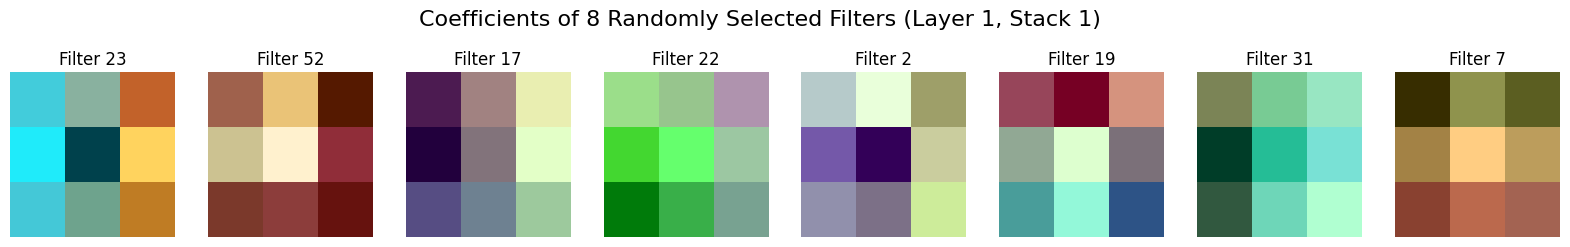

In [7]:
fig, axes = plt.subplots(1, 8, figsize=(20, 3))
fig.suptitle('Coefficients of 8 Randomly Selected Filters (Layer 1, Stack 1)', fontsize=16)

for i, ax in enumerate(axes):
    f = selected_filters[i]
    
    f_min, f_max = f.min(), f.max()
    f_normalized = (f - f_min) / (f_max - f_min)
    
    f_transposed = np.transpose(f_normalized, (1, 2, 0))
    
    ax.imshow(f_transposed)
    ax.set_title(f'Filter {selected_indices[i]}')
    ax.axis('off')

plt.show()

# Display Filter Responses / Feature Maps

In [14]:
image_path = "sample_image.jpg"

Preprocess the image for VGG16

In [15]:
img = Image.open(image_path).convert('RGB')
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
input_tensor = preprocess(img)
input_batch = input_tensor.unsqueeze(0)

Get the output from the first layer

In [16]:
with torch.no_grad(): 
    feature_maps = conv1_layer(input_batch)

feature_maps = feature_maps.squeeze(0).numpy()

# Plot the feature maps for the chosen 8 filters

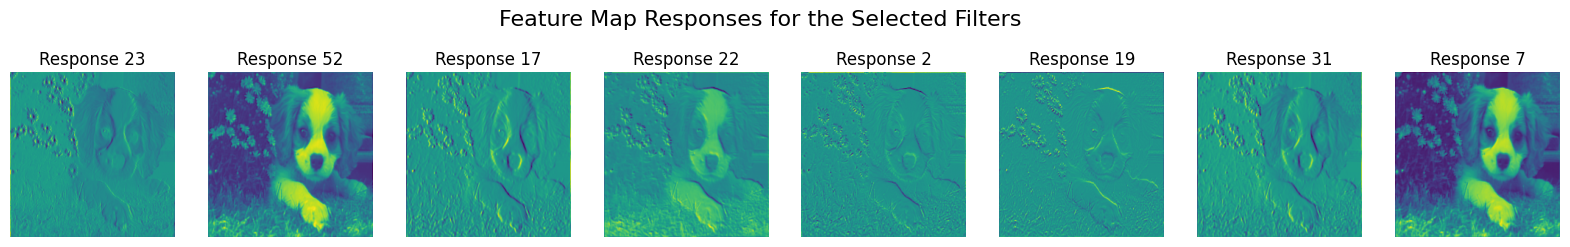

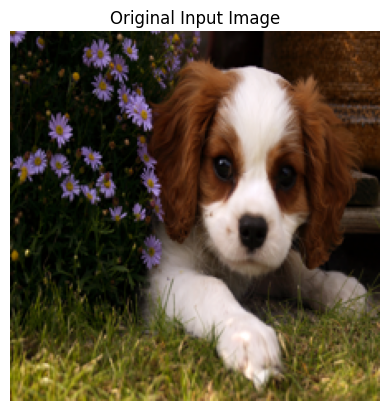

In [17]:
fig, axes = plt.subplots(1, 8, figsize=(20, 3))
fig.suptitle('Feature Map Responses for the Selected Filters', fontsize=16)

for i, ax in enumerate(axes):
    filter_idx = selected_indices[i]
    f_map = feature_maps[filter_idx]
    
    ax.imshow(f_map, cmap='viridis')
    ax.set_title(f'Response {filter_idx}')
    ax.axis('off')

plt.show()
plt.imshow(img.resize((224,224)))
plt.title("Original Input Image")
plt.axis('off')
plt.show()

# Frequency Response and Categorization

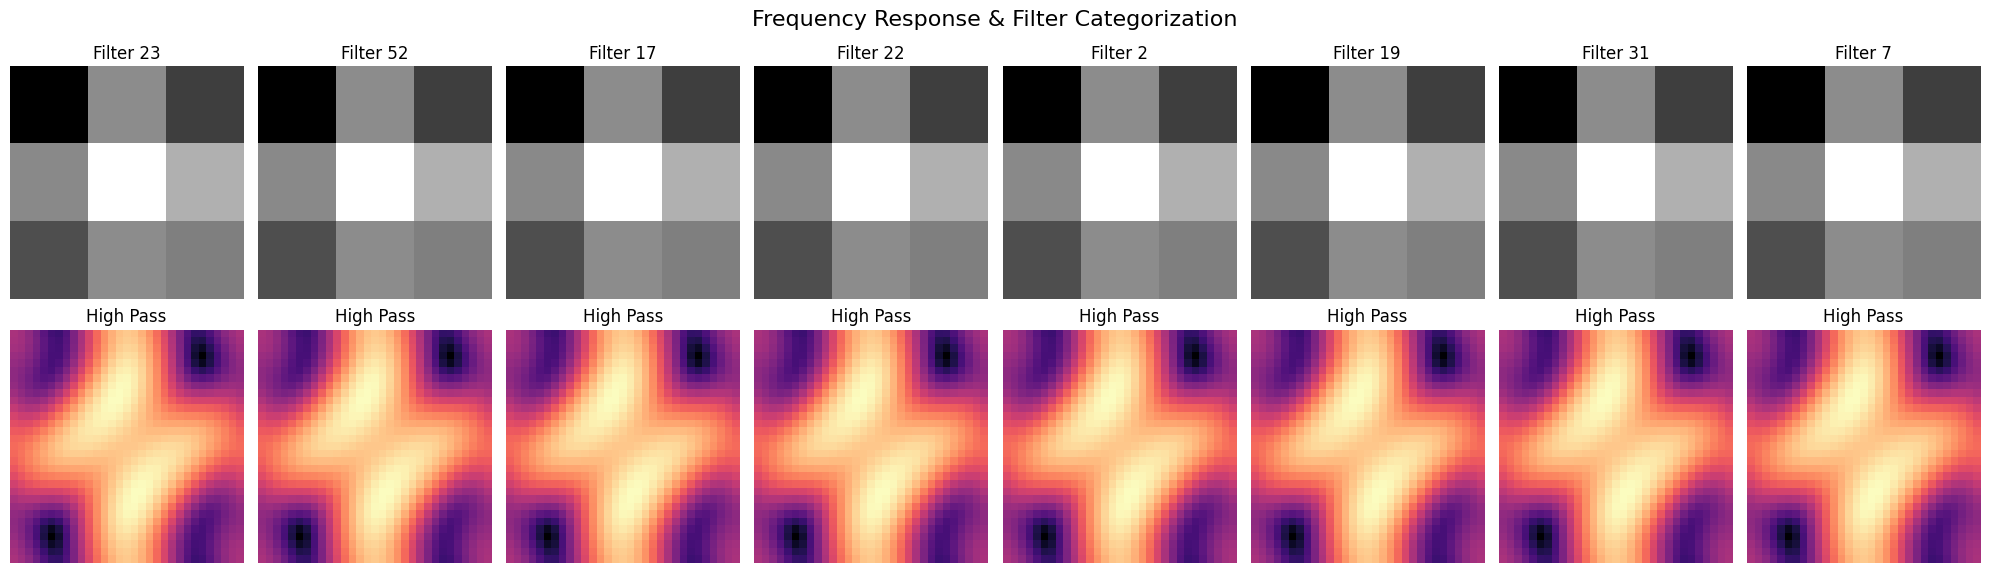

In [18]:
fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.suptitle('Frequency Response & Filter Categorization', fontsize=16)

for i in range(8):
    filter_idx = selected_indices[i]
    f_2d = np.mean(f, axis=0)
    f_padded = np.pad(f_2d, pad_width=14, mode='constant', constant_values=0)
    
    fft_result = np.fft.fft2(f_padded)
    fft_shifted = np.fft.fftshift(fft_result)
    
    magnitude_spectrum = np.abs(fft_shifted)
    
    center_energy = np.sum(magnitude_spectrum[12:20, 12:20]) 
    total_energy = np.sum(magnitude_spectrum)
    
    if (center_energy / total_energy) > 0.40:
        category = "Low Pass"
    else:
        category = "High Pass"
    
    # Plot Spatial Filter (Grayscale)
    axes[0, i].imshow(f_2d, cmap='gray')
    axes[0, i].set_title(f'Filter {filter_idx}')
    axes[0, i].axis('off')
    
    # Plot Frequency Response
    axes[1, i].imshow(magnitude_spectrum, cmap='magma')
    axes[1, i].set_title(category)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()